Getting Started: Importing Packages and Reading the Data

In [78]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib as plt

from xgboost import XGBRegressor
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

df = pd.read_csv("NHANES.csv").drop(["Unnamed: 0", "SEQN"], axis=1)

In [6]:
df.head()

,age,bp_sys,bp_di,weight,height,bmi,waist,kcal,protein,sugar,...,triglycerides,gender,med_hbp,med_chol,extreme_bp,extreme_waist,extreme_hdl,extreme_tri,extreme_glu,metsyn
0,56,108,68,62.1,170.6,21.3,86.6,2840,101.33,148.21,...,48,male,NaN,False,False,False,False,False,True,False
1,22,116,62,74.4,174.1,24.5,86.2,3151,97.12,137.01,...,102,male,NaN,NaN,False,False,False,False,False,False
2,13,102,62,67.0,160.5,26.0,86.0,2224,80.52,162.80,...,80,female,NaN,NaN,False,False,False,False,False,False
3,60,132,68,85.1,154.0,35.9,113.2,1930,79.98,105.06,...,79,female,NaN,NaN,True,True,False,False,True,True
4,60,116,68,56.8,154.6,23.8,89.7,1009,22.69,87.60,...,54,female,NaN,NaN,False,False,False,False,True,False


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2255 entries, 0 to 2254
Data columns (total 28 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SEQN           2255 non-null   int64  
 1   age            2255 non-null   int64  
 2   bp_sys         2255 non-null   int64  
 3   bp_di          2255 non-null   int64  
 4   weight         2255 non-null   float64
 5   height         2255 non-null   float64
 6   bmi            2255 non-null   float64
 7   waist          2255 non-null   float64
 8   kcal           2255 non-null   int64  
 9   protein        2255 non-null   float64
 10  sugar          2255 non-null   float64
 11  carb           2255 non-null   float64
 12  fat_total      2255 non-null   float64
 13  fat_sat        2255 non-null   float64
 14  fat_mon        2255 non-null   float64
 15  fat_poly       2255 non-null   float64
 16  hdl            2255 non-null   int64  
 17  glucose        2255 non-null   int64  
 18  triglyce

In [16]:
df['extreme_bp'].value_counts()

extreme_bp
False    1510
True      745
Name: count, dtype: int64

In [7]:
df['med_hbp'].value_counts()

med_hbp
True     542
False     93
Name: count, dtype: int64

In [19]:
# Split test and training data from within the "Training" dataset
X = df.drop(columns=['extreme_bp', 'bp_sys', 'bp_di'])
y = df['extreme_bp']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=1, stratify=y)

Data Cleaning

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2255 entries, 0 to 2254
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            2255 non-null   int64  
 1   bp_sys         2255 non-null   int64  
 2   bp_di          2255 non-null   int64  
 3   weight         2255 non-null   float64
 4   height         2255 non-null   float64
 5   bmi            2255 non-null   float64
 6   waist          2255 non-null   float64
 7   kcal           2255 non-null   int64  
 8   protein        2255 non-null   float64
 9   sugar          2255 non-null   float64
 10  carb           2255 non-null   float64
 11  fat_total      2255 non-null   float64
 12  fat_sat        2255 non-null   float64
 13  fat_mon        2255 non-null   float64
 14  fat_poly       2255 non-null   float64
 15  hdl            2255 non-null   int64  
 16  glucose        2255 non-null   int64  
 17  triglycerides  2255 non-null   int64  
 18  gender  

In [79]:
# One-hot encode gender
df['gender_M'] = (df['gender']=='male').astype(int)

# One-hot encode 'med_hbp' into 'med_hbp_T' and 'med_hbp_F'
# By creating two columns for T and F, we handle all of the NaN values like a third category
df['med_hbp_T'] = (df['med_hbp'] == True).astype(int)
df['med_hbp_F'] = (df['med_hbp'] == False).astype(int)

# One-hot encode 'med_chol' into 'med_chol_T' and 'med_chol_F'
df['med_chol_T'] = (df['med_chol'] == True).astype(int)
df['med_chol_F'] = (df['med_chol'] == False).astype(int)

# Select boolean columns
bool_columns = df.select_dtypes(include=['bool']).columns

# Convert boolean columns to integers
df[bool_columns] = df[bool_columns].astype(int)

# Drop all columns that needed cleaning or re-encoding
df.drop(['gender', 'med_hbp', 'med_chol'], axis=1, inplace=True)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2255 entries, 0 to 2254
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            2255 non-null   int64  
 1   bp_sys         2255 non-null   int64  
 2   bp_di          2255 non-null   int64  
 3   weight         2255 non-null   float64
 4   height         2255 non-null   float64
 5   bmi            2255 non-null   float64
 6   waist          2255 non-null   float64
 7   kcal           2255 non-null   int64  
 8   protein        2255 non-null   float64
 9   sugar          2255 non-null   float64
 10  carb           2255 non-null   float64
 11  fat_total      2255 non-null   float64
 12  fat_sat        2255 non-null   float64
 13  fat_mon        2255 non-null   float64
 14  fat_poly       2255 non-null   float64
 15  hdl            2255 non-null   int64  
 16  glucose        2255 non-null   int64  
 17  triglycerides  2255 non-null   int64  
 18  extreme_

Split the data into training and test sets

In [60]:
X = df.drop(['extreme_bp','bp_sys','bp_di'], axis=1)
# X = df[['age','bmi','gender_M','hdl']]
y = df.extreme_bp

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,stratify=y, random_state=42)

Convert to DMatrix data type

In [61]:
dtrain = xgb.DMatrix(X_train, y_train)
dtest = xgb.DMatrix(X_test, y_test)

Create the Model

In [74]:
params = {'verbosity': 1,  # Verbosity level: 0-silent, 1-errors, 2-info, 3-debugging
          'max_depth': 6, # max depth of each tree; deeper models are more complex
          'eta': 0.3, # learning_rate; 0-1, where 1 is the highest/quickest (not best)
          'gamma': 0,  # min_split_loss; (0, inf) higher is more conservative
          'lambda': 1, # L2 regularization (0, inf) higher is more conservative
          'alpha': 0, # L1 regularization (0, inf) higher is more conservative
          'tree_method': 'exact', # auto / hist, approx, exact; exact enumerates (more acc, but slow)
          'objective': 'binary:logistic',  # many choices here; binary:logistic outputs probability
          'eval_metric': 'auc'}

num_round = 10

# early_stopping_rounds=10

evallist = [(dtrain, 'train'), (dtest, 'eval')]

boost_model = xgb.train(params, dtrain, num_round, evals=evallist)

[0]	train-auc:0.92246	eval-auc:0.83156
[1]	train-auc:0.93883	eval-auc:0.83879
[2]	train-auc:0.94913	eval-auc:0.85388
[3]	train-auc:0.95640	eval-auc:0.85975
[4]	train-auc:0.96453	eval-auc:0.86698
[5]	train-auc:0.96887	eval-auc:0.87138
[6]	train-auc:0.97268	eval-auc:0.87459
[7]	train-auc:0.97668	eval-auc:0.87489
[8]	train-auc:0.97972	eval-auc:0.87513
[9]	train-auc:0.98347	eval-auc:0.87635


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

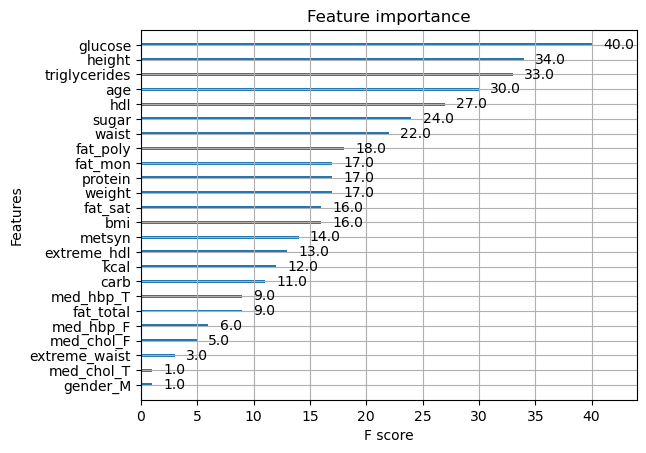

In [68]:
xgb.plot_importance(boost_model)

Moving on to a regression problem

In [80]:
X_reg = df.drop(['extreme_bp', 'bp_sys', 'bp_di'], axis=1)
y_reg = df['bp_sys']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2,stratify=y, random_state=42)

In [81]:
## You may need to reimport and clean the data to run this cell. if so, rerun the cell above

dtrain = xgb.DMatrix(X_train_reg, y_train_reg)
dtest = xgb.DMatrix(X_test_reg, y_test_reg)

In [86]:
params = {'verbosity': 1,  # Verbosity level: 0-silent, 1-errors, 2-info, 3-debugging
          'max_depth': 6, # max depth of each tree; deeper models are more complex
          'eta': 0.3, # learning_rate; 0-1, where 1 is the highest/quickest (not best)
          'gamma': 0,  # min_split_loss; (0, inf) higher is more conservative
          'lambda': 1, # L2 regularization (0, inf) higher is more conservative
          'alpha': 0, # L1 regularization (0, inf) higher is more conservative
          'tree_method': 'exact', # auto / hist, approx, exact; exact enumerates (more acc, but slow)
          'objective': 'reg:squarederror',  # many choices here; binary:logistic outputs probability
          'eval_metric': 'rmse'}

num_round = 20

# early_stopping_rounds=10

evallist = [(dtrain, 'train'), (dtest, 'eval')]

boost_model_reg = xgb.train(params, dtrain, num_round, evals=evallist)

[0]	train-rmse:16.41654	eval-rmse:17.46307
[1]	train-rmse:14.63807	eval-rmse:16.64056
[2]	train-rmse:13.41101	eval-rmse:16.08123
[3]	train-rmse:12.54106	eval-rmse:15.74319
[4]	train-rmse:11.68589	eval-rmse:15.71676
[5]	train-rmse:11.16030	eval-rmse:15.74727
[6]	train-rmse:10.74208	eval-rmse:15.80916
[7]	train-rmse:10.39109	eval-rmse:15.81684
[8]	train-rmse:10.02894	eval-rmse:15.84824
[9]	train-rmse:9.57563	eval-rmse:15.83902
[10]	train-rmse:9.33889	eval-rmse:15.77824
[11]	train-rmse:9.12935	eval-rmse:15.76727
[12]	train-rmse:8.97859	eval-rmse:15.76583
[13]	train-rmse:8.87737	eval-rmse:15.77713
[14]	train-rmse:8.55854	eval-rmse:15.68230
[15]	train-rmse:8.44785	eval-rmse:15.69371
[16]	train-rmse:8.19865	eval-rmse:15.75785
[17]	train-rmse:8.00960	eval-rmse:15.79644
[18]	train-rmse:7.73550	eval-rmse:15.81019
[19]	train-rmse:7.58089	eval-rmse:15.79715


In [85]:
from sklearn.metrics import mean_squared_error

# Using the mean of the actual values as the prediction
mean_bp_sys = np.full_like(df.bp_sys, df.bp_sys.mean())

# Calculate MSE
mse = mean_squared_error(df.bp_sys, mean_bp_sys)

# Calculate RMSE
rmse = round(np.sqrt(mse),4)

print("RMSE using the mean as prediction:", rmse)


RMSE using the mean as prediction: 19.2953


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

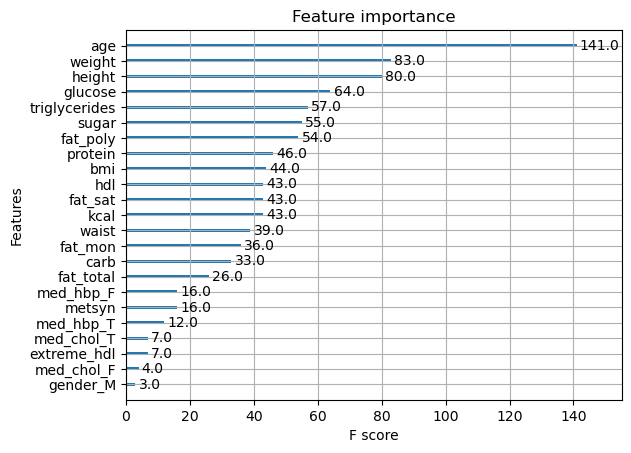

In [87]:
xgb.plot_importance(boost_model_reg)